# Baseline Model

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

train_df = pd.read_csv("datasets/train_hotel_reviews.csv")
test_df = pd.read_csv("datasets/test_hotel_reviews.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (64097, 9)
Test Shape: (16025, 9)


In [2]:
X_train_text = train_df["review_text"]
X_test_text = test_df["review_text"]

y_train = train_df["sentiment"]
y_test = test_df["sentiment"]

In [3]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    min_df=5
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Training Matrix Shape:", X_train.shape)
print("Testing Matrix Shape:", X_test.shape)

Training Matrix Shape: (64097, 10000)
Testing Matrix Shape: (16025, 10000)


## 1. Logistic Regression

In [4]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

#prediction
log_pred = log_model.predict(X_test)

In [5]:
#evaluation
print("Accuracy:",
      accuracy_score(y_test, log_pred))

print()

print(classification_report(
    y_test,
    log_pred
))

Accuracy: 0.8648361934477379

              precision    recall  f1-score   support

           0       0.82      0.68      0.74      4585
           1       0.88      0.94      0.91     11440

    accuracy                           0.86     16025
   macro avg       0.85      0.81      0.83     16025
weighted avg       0.86      0.86      0.86     16025



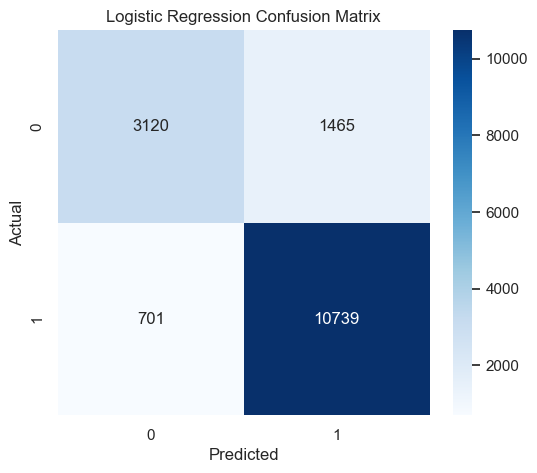

In [6]:
cm = confusion_matrix(
    y_test,
    log_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 2. Naive Bayes

In [7]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

#prediction
nb_pred = nb_model.predict(X_test)

In [8]:
#evaluation
print("Accuracy:",
      accuracy_score(y_test, nb_pred))

print()

print(classification_report(
    y_test,
    nb_pred
))

Accuracy: 0.827207488299532

              precision    recall  f1-score   support

           0       0.85      0.48      0.62      4585
           1       0.82      0.96      0.89     11440

    accuracy                           0.83     16025
   macro avg       0.83      0.72      0.75     16025
weighted avg       0.83      0.83      0.81     16025



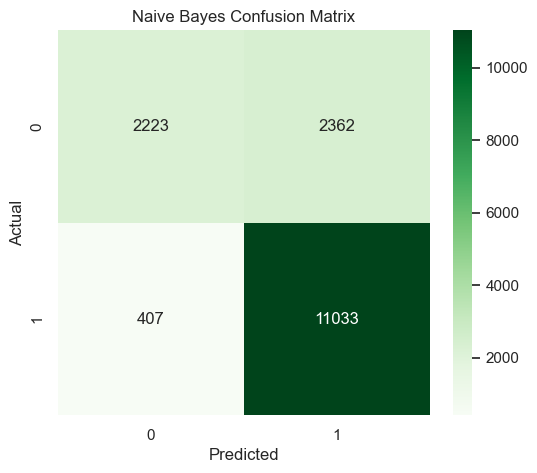

In [9]:
cm = confusion_matrix(
    y_test,
    nb_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 3. Random Forest

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

#prediction
rf_pred = rf_model.predict(X_test)

In [11]:
#evaluation
print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print()

print(classification_report(
    y_test,
    rf_pred
))

Accuracy: 0.8220280811232449

              precision    recall  f1-score   support

           0       0.89      0.43      0.58      4585
           1       0.81      0.98      0.89     11440

    accuracy                           0.82     16025
   macro avg       0.85      0.70      0.73     16025
weighted avg       0.83      0.82      0.80     16025



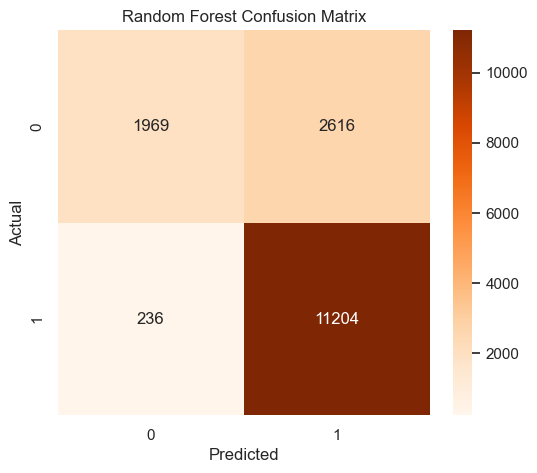

In [12]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

coefficients = log_model.coef_[0]

In [14]:
#most positive words
top_positive = np.argsort(coefficients)[-20:]

positive_words = pd.DataFrame({
    "word": feature_names[top_positive],
    "coefficient": coefficients[top_positive]
})

positive_words.sort_values(
    "coefficient",
    ascending=False
)

,word,coefficient
19,great,8.193971
18,excellent,7.359948
17,perfect,6.581966
16,loved,5.751793
15,comfortable,5.188699
14,wonderful,4.880091
13,nice,4.732207
12,highly,4.696156
11,minor,4.347989
10,definitely,4.305759


In [15]:
#most negative words
top_negative = np.argsort(coefficients)[:20]

negative_words = pd.DataFrame({
    "word": feature_names[top_negative],
    "coefficient": coefficients[top_negative]
})

negative_words.sort_values(
    "coefficient"
)

,word,coefficient
0,average,-6.910063
1,ok,-6.888099
2,poor,-5.999353
3,okay,-5.841526
4,worst,-5.574675
5,disappointing,-5.295853
6,dirty,-5.223894
7,terrible,-4.825215
8,horrible,-4.555875
9,dated,-4.360657


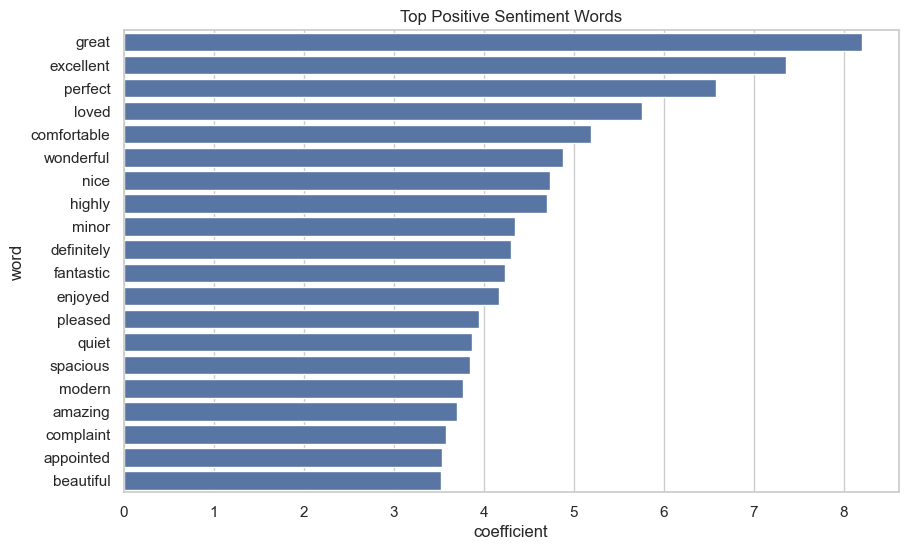

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=positive_words.sort_values(
        "coefficient",
        ascending=False
    ),
    x="coefficient",
    y="word"
)

plt.title("Top Positive Sentiment Words")

plt.show()

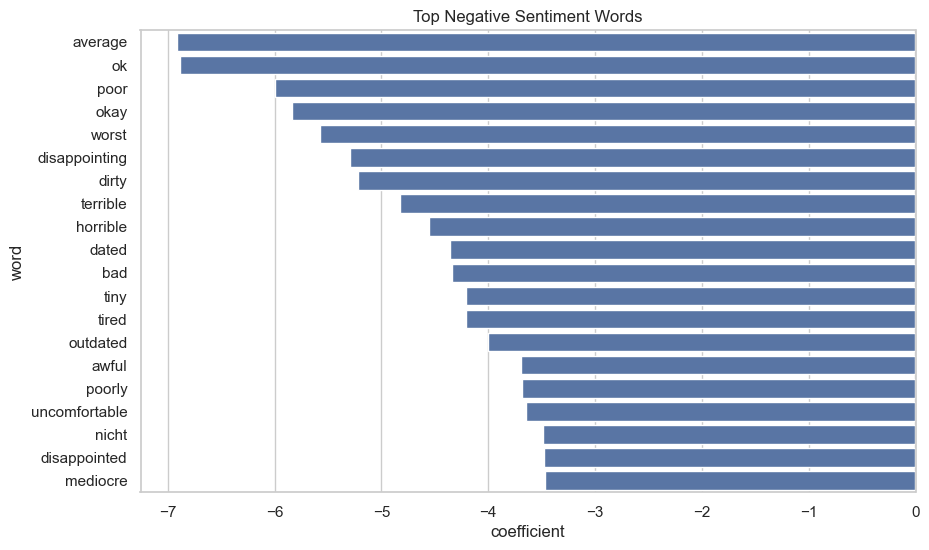

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=negative_words.sort_values(
        "coefficient"
    ),
    x="coefficient",
    y="word"
)

plt.title("Top Negative Sentiment Words")

plt.show()

In [ ]:
# Final baseline comparison table
log_prob = log_model.predict_proba(X_test)[:, 1]
nb_prob = nb_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Naive Bayes",
        "TF-IDF + Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred, zero_division=0),
        precision_score(y_test, nb_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, log_pred, zero_division=0),
        recall_score(y_test, nb_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, log_pred, zero_division=0),
        f1_score(y_test, nb_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, nb_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

results.to_csv(RESULTS_DIR / "baseline_results.csv", index=False)
results.round(4)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8648,0.8800,0.9387,0.9084
1,Naive Bayes,0.8272,0.8237,0.9644,0.8885
2,Random Forest,0.8220,0.8107,0.9794,0.8871


## 4. Save baseline predictions for later comparison/error analysis

In [ ]:
baseline_predictions = test_df[["review_text", "sentiment"]].copy()
baseline_predictions["logistic_probability_positive"] = log_prob
baseline_predictions["logistic_prediction"] = log_pred
baseline_predictions["naive_bayes_probability_positive"] = nb_prob
baseline_predictions["naive_bayes_prediction"] = nb_pred
baseline_predictions["random_forest_probability_positive"] = rf_prob
baseline_predictions["random_forest_prediction"] = rf_pred

baseline_predictions.to_csv(RESULTS_DIR / "baseline_test_predictions.csv", index=False)
print("Saved baseline metrics and predictions to the results folder.")